In [ ]:
import numpy as np
import pandas as pd
import dill 
from tqdm import tqdm
import time
from scipy.stats import qmc
import random
import scipy.stats as stats
from scipy.stats import multivariate_normal

from Forward_model.generate_IC_fixed_grid import get_generate_IC_fixed_grid
from Forward_model.solution_using_FD import get_solution_using_FD
from Forward_model.linear_interpolation import interpolate_linear,interpolate_linear_fill_value
import os

from sklearn.gaussian_process.kernels import Matern
from Forward_model.cubic_spline_interpolation import interpolate_cubicSpline

In [2]:
import matplotlib.pyplot as plt

Artificial time series

In [3]:
#Forward model settings
# Loading ICs
ics={}
with open('Forward_model/IC_ws64_wb0_tb14_H2782_a24634_ic.pkl', 'rb') as f:
    ics=dill.load(f)

EDML=pd.read_excel('Forward_model/paper_site_densities.xlsx')
borehole3000_densityProf=list(EDML['den_EDML'].dropna())
borehole3000_depths= list(EDML['dep_EDML'].dropna())

def get_fwd_param():
    

    ws=64
    Tb=-1.4
    wb=0
    
    m=11
    alpha=2.4634
    beta=0
    velocity=[]
    max_depth=2782
    max_time=500-1
    dt_approx=2**-4
    dz_approx=2**2
    
    return max_depth, max_time, dz_approx, dt_approx, velocity,Tb,alpha,ws, wb,m

def select_ICs(ics,Ts_new):
    ic=ics['%.3f'%(np.round(Ts_new,3))]
       
    return ic

max_depth, max_time, dz_approx, dt_approx, velocity,Tb,alpha,ws, wb,m = get_fwd_param()
tem_ic=select_ICs(ics,-45.000)
fwd_Ts=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, borehole3000_depths, borehole3000_densityProf,velocity,tem_ic,-45.0,Tb,alpha,ws, wb,m)
time_steps=fwd_Ts.times
tim=time_steps+1524#1024

In [4]:
#time vector
t_annual_500yr = np.arange(500)

#Gaussian pulses
pulse1 = np.exp(-((t_annual_500yr - 300) ** 2) / (2 * 25 ** 2))  # Centered at 400, width 50
pulse2 = np.exp(-((t_annual_500yr - 400) ** 2) / (2 * 25 ** 2))  # Centered at 400, width 50
pulse3 = np.exp(-((t_annual_500yr - 500) ** 2) / (2 * 25 ** 2))  # Centered at 500, width 30

#Artificial signal generation
signal_1 = pulse3-45
signal_2 = pulse2-45
signal_3 = pulse1-45
signal_4 = pulse1 + pulse3-45

In [5]:
tem_ic=select_ICs(ics,-45.0)
all_signals=[signal_1,signal_2,signal_3,signal_4]
all_Ts_signals=[]
all_fwds=[]

for s in all_signals:
    Ts=interpolate_cubicSpline(x_ref=t_annual_500yr,y_ref=s,x_req=fwd_Ts.times)
    all_Ts_signals.append(Ts)
    fwd=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, borehole3000_depths, borehole3000_densityProf,
                              velocity,tem_ic,Ts,Tb,alpha,ws, wb,m)
    all_fwds.append(fwd)



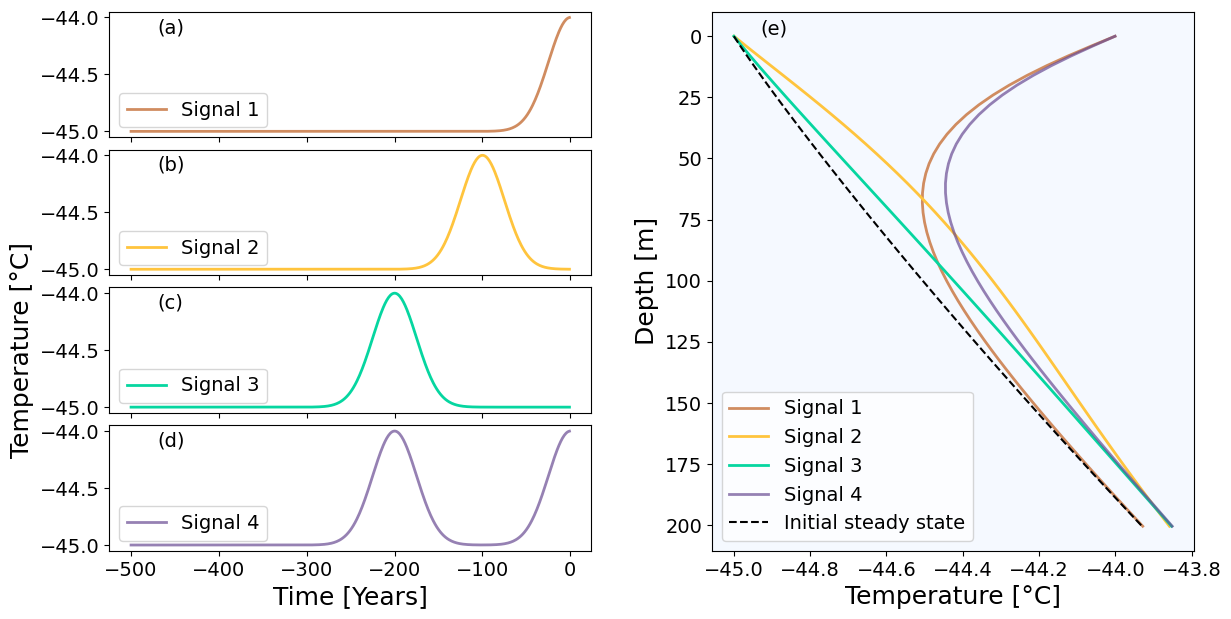

In [14]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(14, 7))

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

outer_gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

signals = [signal_1, signal_2, signal_3, signal_4]
labels  = ['Signal 1', 'Signal 2', 'Signal 3', 'Signal 4']
colors_r  = ['#f25f5c', '#247ba0', '#50514f']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
alphas=[1,1,1,0.7]
subplotlabels  = ['(a)', '(b)', '(c)', '(d)','(e)']
left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    ax.plot(t_annual_500yr - 500, signals[i],
            color=colors[i], label=labels[i], alpha=alphas[i],lw=2)
    # ax.axhline(y=-45, color=colors_r[0], linestyle='--', linewidth=2)
    # ax.axhline(y=-44.4, color=colors_r[1], linestyle='--', linewidth=2)
    # ax.axhline(y=-44.8, color=colors_r[2], linestyle='--', linewidth=2)
    ax.text(0.1, 0.95, subplotlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    ax.legend(loc='lower left',fontsize=14)
    left_axes.append(ax)
    

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
ax_right = fig.add_subplot(outer_gs[1])

for i in range(4):
    
    ax_right.plot(all_fwds[i].T[:51,-1], all_fwds[i].depths[:51],
              color=colors[i], label=labels[i], alpha=alphas[i],lw=2)
ax_right.plot(all_fwds[0].T[:51,0], all_fwds[0].depths[:51],
              color='black',linestyle='dashed', label='Initial steady state')
ax_right.invert_yaxis()
ax_right.set_xlabel('Temperature [°C]', fontsize=18)
ax_right.set_ylabel('Depth [m]',fontsize=18)
ax_right.legend(loc='lower left', fontsize=14)
ax_right.text(0.1, 0.95, subplotlabels[4], horizontalalignment='left', verticalalignment='bottom', transform=ax_right.transAxes,fontsize=14)
ax_right.set_facecolor('#F5F9FF')     
# plt.savefig('Figures/fig_art_data.png', dpi=300)
plt.show()


Measured depths

In [7]:
measured_depths_40eq=np.linspace(0,200,40)
measured_depths_30eq=np.linspace(0,200,30)
measured_depths_20eq=np.linspace(0,200,20)

Generating measurements

In [8]:
measured_temps_40eq_signal_1 = interpolate_cubicSpline(x_ref=all_fwds[0].depths,y_ref=all_fwds[0].T[:,-1],x_req=measured_depths_40eq)
measured_temps_30eq_signal_1 = interpolate_cubicSpline(x_ref=all_fwds[0].depths,y_ref=all_fwds[0].T[:,-1],x_req=measured_depths_30eq) 
measured_temps_20eq_signal_1 = interpolate_cubicSpline(x_ref=all_fwds[0].depths,y_ref=all_fwds[0].T[:,-1],x_req=measured_depths_20eq)

In [9]:
measured_temps_40eq_signal_2 = interpolate_cubicSpline(x_ref=all_fwds[1].depths,y_ref=all_fwds[1].T[:,-1],x_req=measured_depths_40eq)
measured_temps_30eq_signal_2 = interpolate_cubicSpline(x_ref=all_fwds[1].depths,y_ref=all_fwds[1].T[:,-1],x_req=measured_depths_30eq) 
measured_temps_20eq_signal_2 = interpolate_cubicSpline(x_ref=all_fwds[1].depths,y_ref=all_fwds[1].T[:,-1],x_req=measured_depths_20eq)

In [10]:
measured_temps_40eq_signal_3 = interpolate_cubicSpline(x_ref=all_fwds[2].depths,y_ref=all_fwds[2].T[:,-1],x_req=measured_depths_40eq)
measured_temps_30eq_signal_3 = interpolate_cubicSpline(x_ref=all_fwds[2].depths,y_ref=all_fwds[2].T[:,-1],x_req=measured_depths_30eq) 
measured_temps_20eq_signal_3 = interpolate_cubicSpline(x_ref=all_fwds[2].depths,y_ref=all_fwds[2].T[:,-1],x_req=measured_depths_20eq)

In [11]:
measured_temps_40eq_signal_4 = interpolate_cubicSpline(x_ref=all_fwds[3].depths,y_ref=all_fwds[3].T[:,-1],x_req=measured_depths_40eq)
measured_temps_30eq_signal_4 = interpolate_cubicSpline(x_ref=all_fwds[3].depths,y_ref=all_fwds[3].T[:,-1],x_req=measured_depths_30eq) 
measured_temps_20eq_signal_4 = interpolate_cubicSpline(x_ref=all_fwds[3].depths,y_ref=all_fwds[3].T[:,-1],x_req=measured_depths_20eq)

In [12]:
Artificial_measurements_4_2_temps_40eq_signal_1=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_40eq_signal_1.npy') 
Artificial_measurements_4_2_temps_40eq_signal_2=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_40eq_signal_2.npy') 
Artificial_measurements_4_2_temps_40eq_signal_3=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_40eq_signal_3.npy') 
Artificial_measurements_4_2_temps_40eq_signal_4=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_40eq_signal_4.npy') 
    
Artificial_measurements_4_2_temps_30eq_signal_1=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_30eq_signal_1.npy') 
Artificial_measurements_4_2_temps_30eq_signal_2=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_30eq_signal_2.npy') 
Artificial_measurements_4_2_temps_30eq_signal_3=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_30eq_signal_3.npy') 
Artificial_measurements_4_2_temps_30eq_signal_4=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_30eq_signal_4.npy') 

Artificial_measurements_4_2_temps_20eq_signal_1=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_20eq_signal_1.npy')
Artificial_measurements_4_2_temps_20eq_signal_2=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_20eq_signal_2.npy')
Artificial_measurements_4_2_temps_20eq_signal_3=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_20eq_signal_3.npy')
Artificial_measurements_4_2_temps_20eq_signal_4=np.load('Data/Gaussian_pulse_signals/Artificial_measurements/Artificial_measurements_4_2_temps_20eq_signal_4.npy')

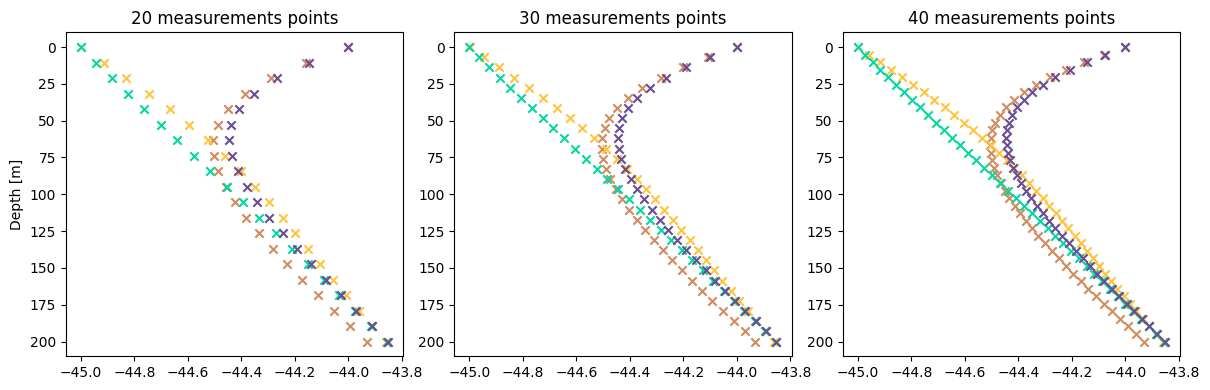

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

# Plot on each subplot

axes[0].scatter(Artificial_measurements_4_2_temps_20eq_signal_1, measured_depths_20eq, color=colors[0],label='Signal_1', marker='x')
axes[0].scatter(Artificial_measurements_4_2_temps_20eq_signal_2, measured_depths_20eq, color=colors[1],label='Signal_2', marker='x')
axes[0].scatter(Artificial_measurements_4_2_temps_20eq_signal_3, measured_depths_20eq, color=colors[2],label='Signal_3', marker='x')
axes[0].scatter(Artificial_measurements_4_2_temps_20eq_signal_4, measured_depths_20eq, color=colors[3],label='Signal_4', marker='x')
axes[0].set_title('20 measurements points')
axes[0].invert_yaxis()
axes[0].set_ylabel('Depth [m]')


axes[1].scatter(Artificial_measurements_4_2_temps_30eq_signal_1, measured_depths_30eq, color=colors[0],label='Signal_1', marker='x')
axes[1].scatter(Artificial_measurements_4_2_temps_30eq_signal_2, measured_depths_30eq, color=colors[1],label='Signal_2', marker='x')
axes[1].scatter(Artificial_measurements_4_2_temps_30eq_signal_3, measured_depths_30eq, color=colors[2],label='Signal_3', marker='x')
axes[1].scatter(Artificial_measurements_4_2_temps_30eq_signal_4, measured_depths_30eq, color=colors[3],label='Signal_4', marker='x')
axes[1].set_title('30 measurements points')
axes[1].invert_yaxis()

axes[2].scatter(Artificial_measurements_4_2_temps_40eq_signal_1, measured_depths_40eq, color=colors[0],label='Signal_1', marker='x')
axes[2].scatter(Artificial_measurements_4_2_temps_40eq_signal_2, measured_depths_40eq, color=colors[1],label='Signal_2', marker='x')
axes[2].scatter(Artificial_measurements_4_2_temps_40eq_signal_3, measured_depths_40eq, color=colors[2],label='Signal_3', marker='x')
axes[2].scatter(Artificial_measurements_4_2_temps_40eq_signal_4, measured_depths_40eq, color=colors[3],label='Signal_4', marker='x')
axes[2].set_title('40 measurements points')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()